In [1]:
# Week 3 — Sharpe Ratio, Options Intuition and Correlation

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["SPY", "QQQ", "GLD", "TLT"]
prices = yf.download(tickers, period="1y")["Close"]
prices.columns = prices.columns.get_level_values(0)
returns = prices.pct_change().dropna()

risk_free_daily = 0.045 / 252

sharpe = pd.DataFrame({
    "Ann. Return (%)":  (returns.mean() * 252 * 100).round(2),
    "Ann. Vol (%)":     (returns.std() * np.sqrt(252) * 100).round(2),
    "Sharpe (proper)":  (
        (returns.mean() - risk_free_daily) * 252 /
        (returns.std() * np.sqrt(252))
    ).round(2),
    "Max Drawdown (%)": (
        ((prices / prices.cummax()) - 1).min() * 100
    ).round(2)
})
print(sharpe)
#Max drawdown = worst peak-to-trough loss. A strategy with high Sharpe but -40% max drawdown is still hard to hold in practice. Always show both.

[*********************100%***********************]  4 of 4 completed


        Ann. Return (%)  Ann. Vol (%)  Sharpe (proper)  Max Drawdown (%)
Ticker                                                                  
GLD               33.93         26.76             1.10            -19.21
QQQ               36.76         16.01             2.02            -11.96
SPY               26.66         11.86             1.87             -8.88
TLT                4.48          9.85            -0.00             -7.58


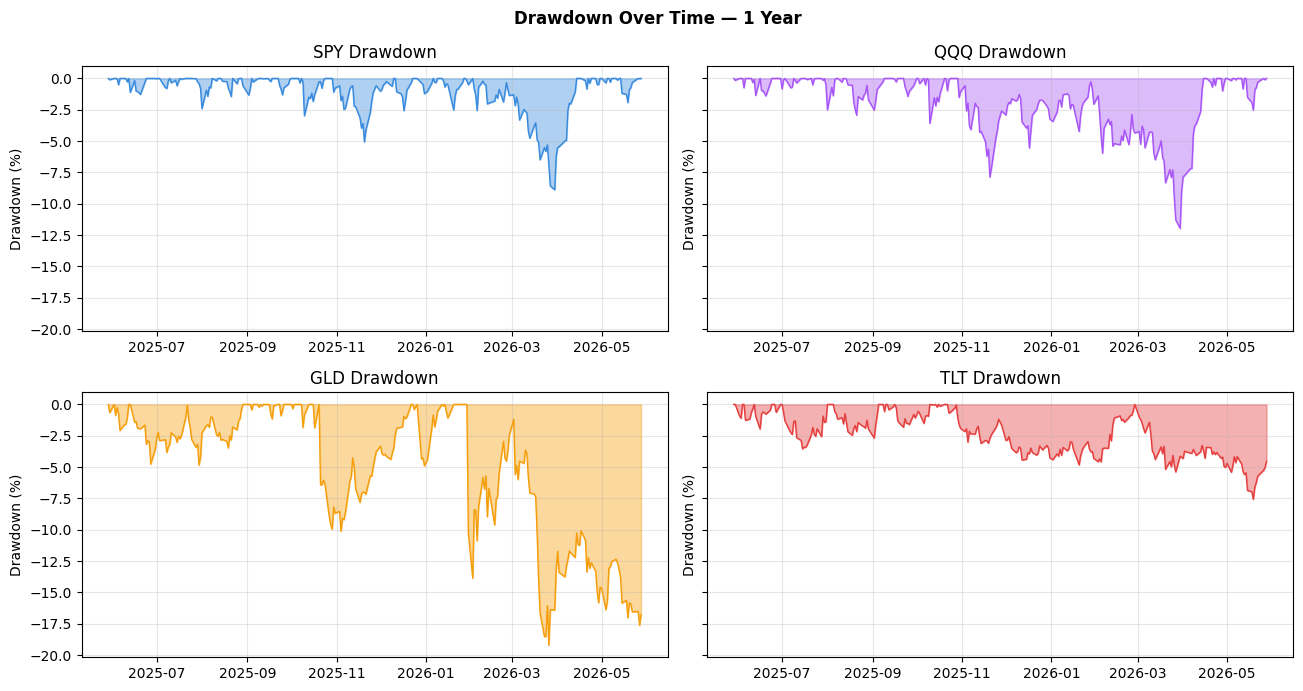

In [3]:
#Plot drawdown over time for each asset
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=True)
axes = axes.flatten()
colors = {"SPY":"#378ADD","QQQ":"#A855F7","GLD":"#F59E0B","TLT":"#E53E3E"}

for i, ticker in enumerate(tickers):
    dd = (prices[ticker] / prices[ticker].cummax() - 1) * 100
    axes[i].fill_between(dd.index, dd.values, 0,
                         color=colors[ticker], alpha=0.4)
    axes[i].plot(dd.index, dd.values, color=colors[ticker], linewidth=1)
    axes[i].set_title(f"{ticker} Drawdown")
    axes[i].set_ylabel("Drawdown (%)")
    axes[i].grid(alpha=0.3)

plt.suptitle("Drawdown Over Time — 1 Year", fontweight="bold")
plt.tight_layout()
plt.show()
#ℹ Deeper + longer shaded area = more painful to hold. A strategy that recovers quickly from drawdowns is far more tradeable than one that stays underwater for months.

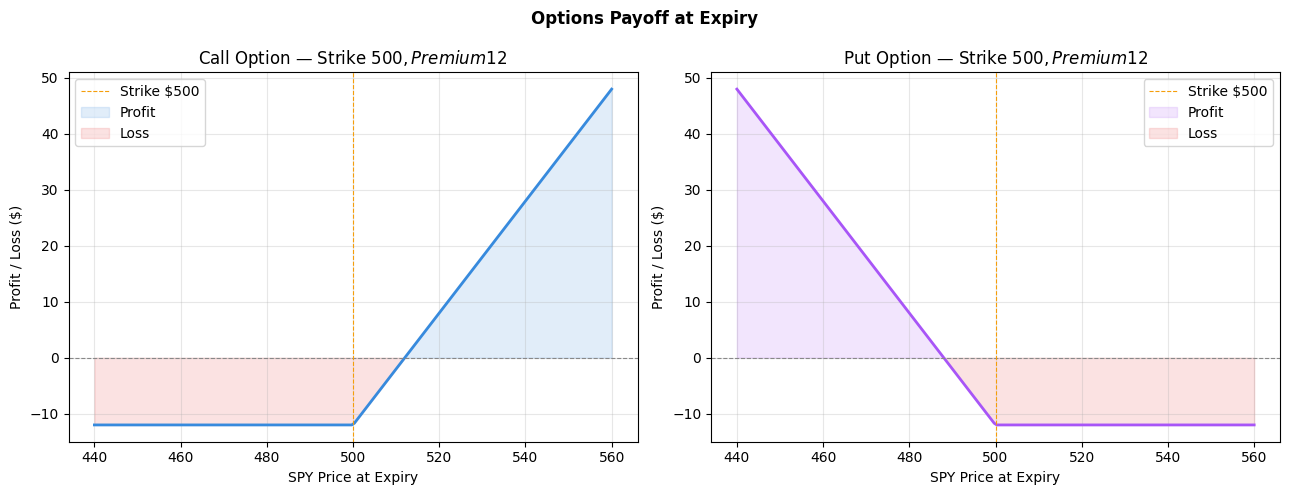

In [4]:
#Plot call and put payoff diagrams
import numpy as np
import matplotlib.pyplot as plt

strike = 500
premium = 12
prices_range = np.linspace(440, 560, 200)

call_payoff = np.maximum(prices_range - strike, 0) - premium
put_payoff  = np.maximum(strike - prices_range, 0) - premium

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, payoff, label, col in [
    (ax1, call_payoff, "Call", "#378ADD"),
    (ax2, put_payoff,  "Put",  "#A855F7")
]:
    ax.plot(prices_range, payoff, color=col, linewidth=2)
    ax.axhline(0, color="#888", linewidth=0.8, linestyle="--")
    ax.axvline(strike, color="#F59E0B", linewidth=0.8,
               linestyle="--", label=f"Strike ${strike}")
    ax.fill_between(prices_range, payoff, 0,
        where=(payoff>0), color=col, alpha=0.15, label="Profit")
    ax.fill_between(prices_range, payoff, 0,
        where=(payoff<0), color="#E53E3E", alpha=0.15, label="Loss")
    ax.set_title(f"{label} Option — Strike ${strike}, Premium ${premium}")
    ax.set_xlabel("SPY Price at Expiry")
    ax.set_ylabel("Profit / Loss ($)")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Options Payoff at Expiry", fontweight="bold")
plt.tight_layout()
plt.show()
#ℹ Flat loss region = your premium cap. Call profit is theoretically unlimited. Put profit is capped at (strike − premium) since a stock can't go below zero.

[*********************100%***********************]  6 of 6 completed


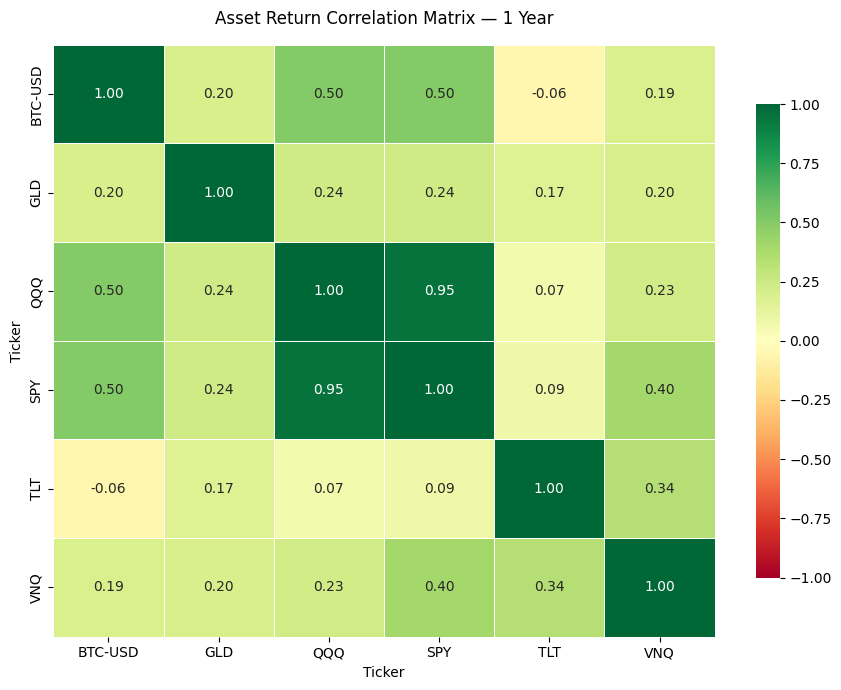

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tickers = ["SPY","QQQ","GLD","TLT","BTC-USD","VNQ"]
prices = yf.download(tickers, period="1y")["Close"]
prices.columns = prices.columns.get_level_values(0)
returns = prices.pct_change().dropna()

corr = returns.corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Asset Return Correlation Matrix — 1 Year", pad=15)
plt.tight_layout()
plt.show()

1. Which two assets are most correlated? Does that make sense intuitively? QQQ and SPY. Yes because a large part of SPY consists of QQQ stocks
SPY tracks the S&P 500 and QQQ tracks the Nasdaq 100 — the top Nasdaq stocks (Apple, Microsoft, Nvidia, Amazon) are also the largest weights in SPY. So you're largely measuring the same companies twice. A 0.95 correlation means they're almost redundant from a diversification perspective. Holding both is not meaningfully different from holding one.
2. Which asset has the lowest average correlation to everything else? TLT That's your best diversifier.
TLT's correlations: -0.06 with BTC, 0.17 with GLD, 0.07 with QQQ, 0.09 with SPY, 0.34 with VNQ. The average is roughly 0.12 — lowest of all six assets by a wide margin. Adding TLT to a portfolio of equities reduces overall volatility without requiring you to give up much return when used in the right proportion.m
3. Is TLT negatively correlated with SPY? Historically yes — has that held this past year? No. It is positively correlated.
The traditional negative correlation (bonds up, stocks down) held for roughly 20 years (2000–2021) because whenever stocks fell, central banks cut rates, which pushed bond prices up. That relationship broke in 2022 when inflation forced the Fed to raise rates aggressively — both stocks and bonds fell simultaneously. The past year's 0.09 reflects a partial normalisation but not a full return to the historical negative relationship. This is a genuinely important macro point — don't assume the stock-bond hedge always works.
4. Where does BTC sit? Crypto was supposed to be uncorrelated with stocks — has that changed? Yes it is positively correlated now
Pre-2020, BTC correlation with equities was near zero — it traded on its own crypto-native catalysts. Post-2020, institutional money entered the market. When large funds need liquidity in a crisis they sell everything — including BTC. This forced BTC to become correlated with risk assets during stress periods. A 0.50 correlation with SPY means BTC now behaves more like a high-volatility tech stock than a true alternative asset. It still offers some diversification benefit, but the "digital gold uncorrelated to everything" narrative has largely broken down.

# Month 1 Summary — What I Built and Learned

## Week 1 — Python for Finance Foundations
- Set up a Jupyter environment with pandas, numpy, matplotlib and yfinance
- Downloaded 1 year of OHLCV data for SPY and computed daily returns
- Plotted normalised price performance across SPY, QQQ, GLD, TLT
- Built a stock screener filtering by trend, volatility and return

## Week 2 — Returns, Volatility and Market Structure
- Understood the difference between simple and log returns and when to use each
- Computed 20-day rolling volatility and observed how it spikes during market stress
- Built a 50/200-day moving average crossover chart and detected golden/death crosses in code
- Computed VWAP as a daily execution benchmark and compared it against closing price
- Plotted SPY returns distribution and measured kurtosis — confirmed fat tails above normal

## Week 3 — Finance Theory
- Computed proper Sharpe ratio subtracting risk-free rate across 4 asset classes
- Added max drawdown to the summary table — identified QQQ as strongest on Sharpe
  but noted single-year lookback limitation and 2022 precedent
- Built call and put payoff diagrams — understood intrinsic value vs time value
- Computed a 6-asset correlation heatmap and interpreted key findings:
  - QQQ/SPY most correlated (0.95) — largely redundant for diversification
  - TLT best diversifier (avg correlation ~0.12 across all assets)
  - TLT/SPY correlation historically negative but broke down post-2022 rate hikes
  - BTC now 0.50 correlated with SPY — institutional flows eroded the uncorrelated narrative

## Key Takeaways
- Sharpe and max drawdown must be read together — one measures average experience,
  the other measures worst experience
- Fat tails mean normal distribution models underestimate real risk — always check kurtosis
- Correlation going to 1 in a crisis means diversification often fails exactly when needed most
- A high Sharpe over one year is not reliable — need 3-5 years minimum to trust it

## Deliverable
Stock screener + multi-week analysis notebook pushed to GitHub.
All code uses live market data pulled via yfinance.